In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import time

from networkx.algorithms.community import (
    louvain_communities,
    girvan_newman,
    modularity
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:

G = nx.karate_club_graph()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

Number of Nodes: 34
Number of Edges: 78


In [4]:

print("Node   Degree")

for node in G.nodes():
    print(f"{node:4}   {G.degree(node):6}")

Node   Degree
   0       16
   1        9
   2       10
   3        6
   4        3
   5        4
   6        4
   7        4
   8        5
   9        2
  10        3
  11        1
  12        2
  13        5
  14        2
  15        2
  16        2
  17        2
  18        2
  19        3
  20        2
  21        2
  22        2
  23        5
  24        3
  25        3
  26        2
  27        4
  28        3
  29        4
  30        4
  31        6
  32       12
  33       17


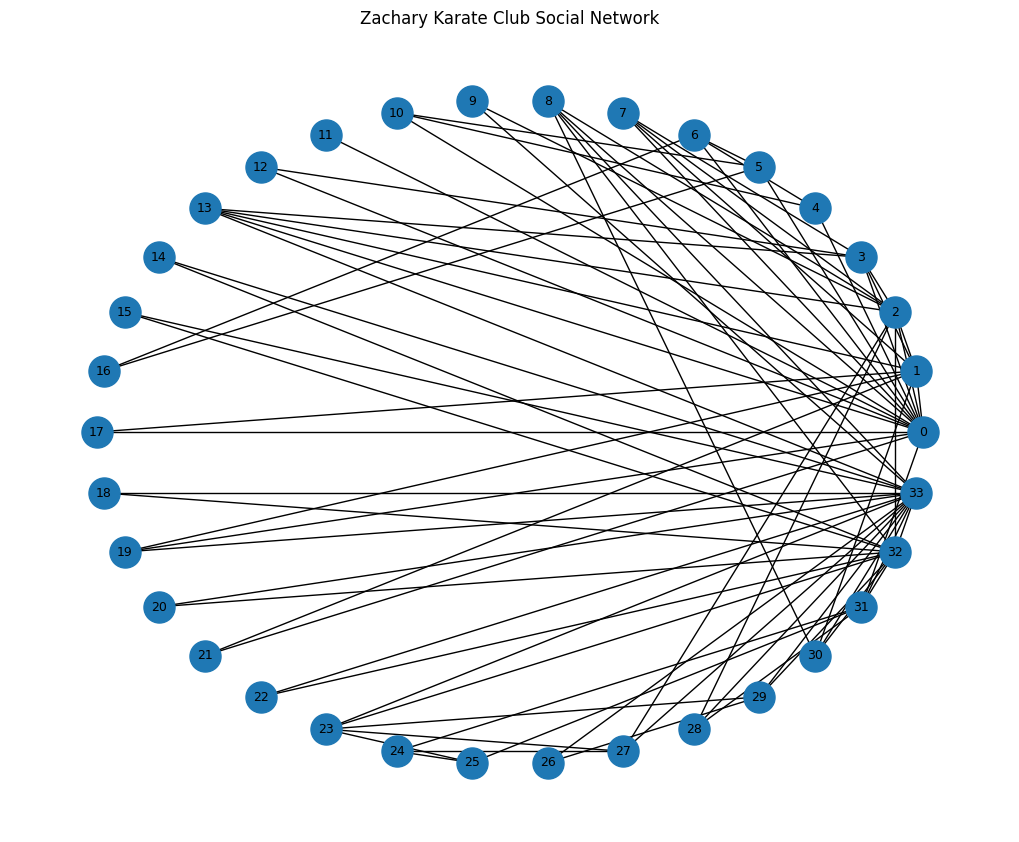

In [5]:

plt.figure(figsize=(10, 8))

nx.draw_circular(
    G,
    with_labels=True,
    node_size=500,
    font_size=9
)

plt.title("Zachary Karate Club Social Network")

plt.show()


 LOUVAIN COMMUNITY DETECTION



In [6]:


start_time = time.time()

louvain_communities_result = louvain_communities(
    G,
    seed=42
)

louvain_time = time.time() - start_time

print("Louvain Community Detection")
print("--------------------------------")
print("Number of communities:",
      len(louvain_communities_result))

print("Execution time:",
      round(louvain_time, 6),
      "seconds")

Louvain Community Detection
--------------------------------
Number of communities: 4
Execution time: 0.005265 seconds


LOUVIAN COMMUNITY

In [7]:

for i, community in enumerate(louvain_communities_result):

    print(
        f"Community {i + 1}:",
        sorted(community)
    )

Community 1: [1, 2, 3, 7, 12, 13]
Community 2: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
Community 3: [24, 25, 28, 31]
Community 4: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]


COMMUNITY SIZES

In [9]:
print("Louvain Community Sizes")
print("-----------------------")

for i, community in enumerate(louvain_communities_result):

    print(
        f"Community {i + 1}: {len(community)} nodes"
    )

Louvain Community Sizes
-----------------------
Community 1: 6 nodes
Community 2: 10 nodes
Community 3: 4 nodes
Community 4: 14 nodes


Louvain Modularity

Higher modularity means the detected communities have stronger internal connections and fewer connections between communities.


In [10]:


louvain_modularity = modularity(
    G,
    louvain_communities_result
)

print(
    "Louvain Modularity:",
    round(louvain_modularity, 4)
)

Louvain Modularity: 0.4266


In [11]:

louvain_labels = {}

for community_id, community in enumerate(
    louvain_communities_result
):

    for node in community:

        louvain_labels[node] = community_id

print("Community labels created!")

Community labels created!


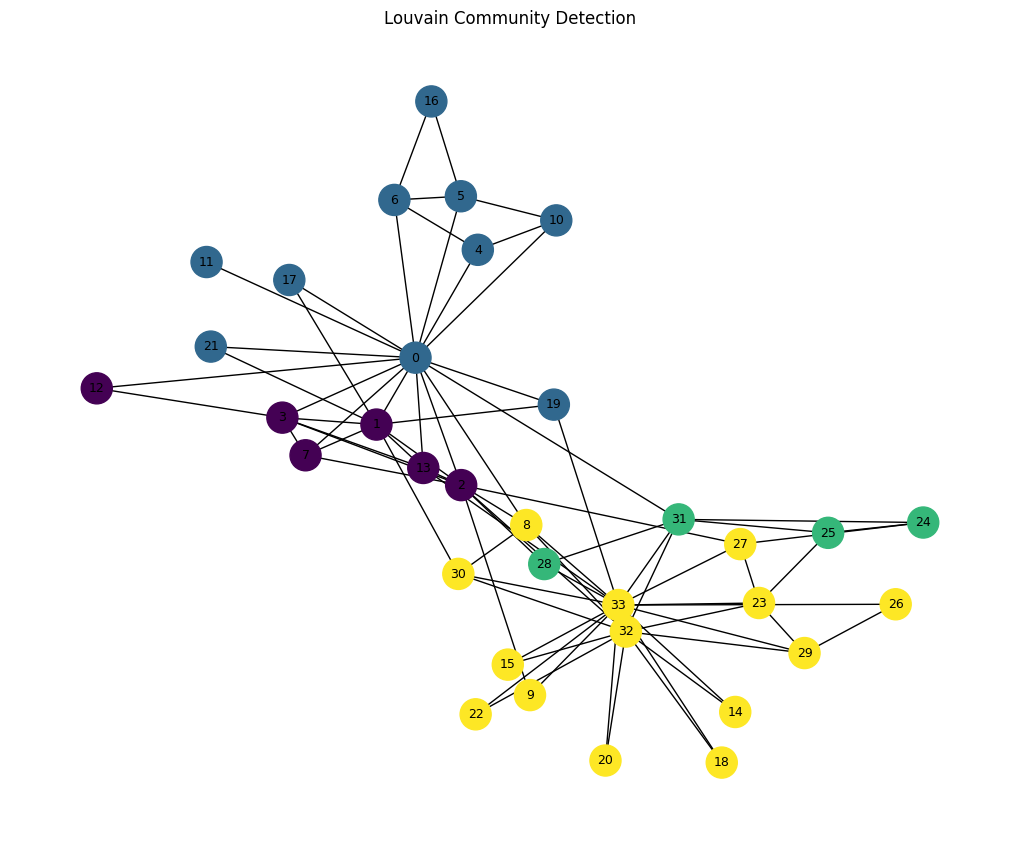

In [12]:

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(
    G,
    seed=42
)

node_colors = [
    louvain_labels[node]
    for node in G.nodes()
]

nx.draw(
    G,
    pos,
    node_color=node_colors,
    with_labels=True,
    node_size=500,
    font_size=9
)

plt.title("Louvain Community Detection")

plt.show()

Girvan–Newman


In [13]:
start_time = time.time()

gn_generator = girvan_newman(G)


gn_communities_result = next(gn_generator)

gn_time = time.time() - start_time

print("Girvan-Newman Community Detection")
print("-----------------------------------")

print(
    "Number of communities:",
    len(gn_communities_result)
)

print(
    "Execution time:",
    round(gn_time, 6),
    "seconds"
)

Girvan-Newman Community Detection
-----------------------------------
Number of communities: 2
Execution time: 0.034223 seconds


In [15]:
for i, community in enumerate(
    gn_communities_result
):

    print(
        f"Community {i + 1}:",
        sorted(community)
    )

Community 1: [0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]
Community 2: [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


MODULARITY

In [16]:

gn_modularity = modularity(
    G,
    gn_communities_result
)

print(
    "Girvan-Newman Modularity:",
    round(gn_modularity, 4)
)

Girvan-Newman Modularity: 0.3477


In [17]:

gn_labels = {}

for community_id, community in enumerate(
    gn_communities_result
):

    for node in community:

        gn_labels[node] = community_id

print("Girvan-Newman labels created!")

Girvan-Newman labels created!


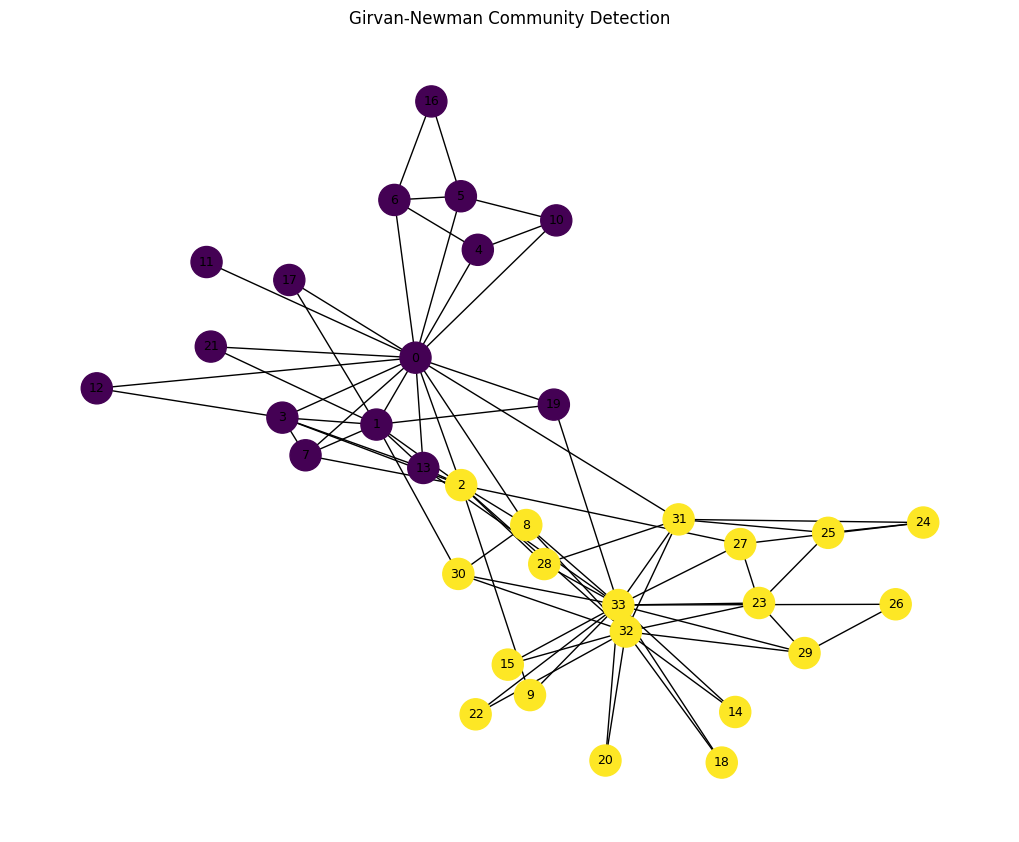

In [18]:
plt.figure(figsize=(10, 8))

node_colors_gn = [
    gn_labels[node]
    for node in G.nodes()
]

nx.draw(
    G,
    pos,
    node_color=node_colors_gn,
    with_labels=True,
    node_size=500,
    font_size=9
)

plt.title(
    "Girvan-Newman Community Detection"
)

plt.show()

COMMUNITY QUALITY ANALYSIS

In [19]:

gn_generator = girvan_newman(G)

gn_4_communities = None

for communities in gn_generator:

    if len(communities) >= 4:
        gn_4_communities = communities
        break

print("Number of Girvan-Newman communities:",
      len(gn_4_communities))

print("\nCommunity sizes:")

for i, community in enumerate(gn_4_communities):
    print(
        f"Community {i+1}: {len(community)} nodes"
    )

Number of Girvan-Newman communities: 4

Community sizes:
Community 1: 10 nodes
Community 2: 18 nodes
Community 3: 5 nodes
Community 4: 1 nodes


In [21]:
gn_modularity_4 = modularity(
    G,
    gn_4_communities
)

print(
    "Girvan-Newman Modularity:",
    round(gn_modularity_4, 4)
)

Girvan-Newman Modularity: 0.3581


Density = Actual edges / Possible edges

In [22]:


def calculate_community_densities(G, communities):

    densities = []

    for community in communities:

        subgraph = G.subgraph(community)

        density = nx.density(subgraph)

        densities.append(density)

    return densities

In [23]:
louvain_densities = calculate_community_densities(
    G,
    louvain_communities_result
)

print("Louvain Community Densities:")

for i, density in enumerate(louvain_densities):

    print(
        f"Community {i+1}:",
        round(density, 4)
    )

Louvain Community Densities:
Community 1: 0.6667
Community 2: 0.3111
Community 3: 0.6667
Community 4: 0.2857


In [24]:
gn_densities = calculate_community_densities(
    G,
    gn_4_communities
)

print("\nGirvan-Newman Community Densities:")

for i, density in enumerate(gn_densities):

    print(
        f"Community {i+1}:",
        round(density, 4)
    )


Girvan-Newman Community Densities:
Community 1: 0.4
Community 2: 0.2484
Community 3: 0.6
Community 4: 0


In [26]:

 #AVERAGE COMMUNITY DENSITY


louvain_avg_density = sum(
    louvain_densities
) / len(louvain_densities)

gn_avg_density = sum(
    gn_densities
) / len(gn_densities)

print(
    "Louvain Average Community Density:",
    round(louvain_avg_density, 4)
)

print(
    "Girvan-Newman Average Community Density:",
    round(gn_avg_density, 4)
)

Louvain Average Community Density: 0.4825
Girvan-Newman Average Community Density: 0.3121


In [27]:

comparison_df = pd.DataFrame({

    "Algorithm": [
        "Louvain",
        "Girvan-Newman"
    ],

    "Number_of_Communities": [
        len(louvain_communities_result),
        len(gn_4_communities)
    ],

    "Modularity": [
        louvain_modularity,
        gn_modularity_4
    ],

    "Average_Community_Density": [
        louvain_avg_density,
        gn_avg_density
    ],

    "Execution_Time_Seconds": [
        louvain_time,
        gn_time
    ]
})

print("===== COMMUNITY QUALITY COMPARISON =====")

display(comparison_df)

===== COMMUNITY QUALITY COMPARISON =====


,Algorithm,Number_of_Communities,Modularity,Average_Community_Density,Execution_Time_Seconds
0,Louvain,4,0.426622,0.482540,0.005265
1,Girvan-Newman,4,0.358061,0.312092,0.034223


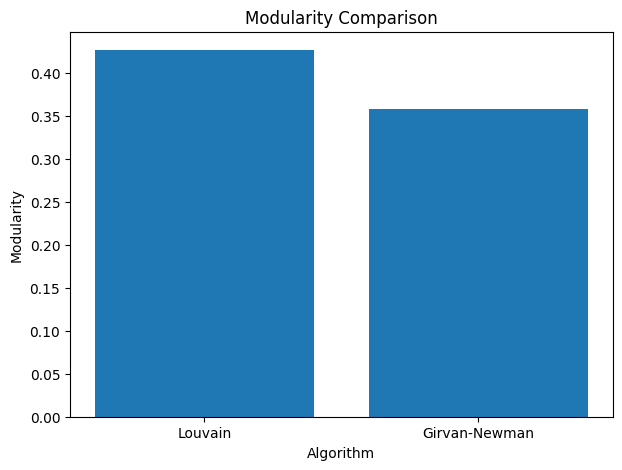

In [28]:

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Modularity"]
)

plt.ylabel("Modularity")
plt.xlabel("Algorithm")
plt.title("Modularity Comparison")

plt.show()

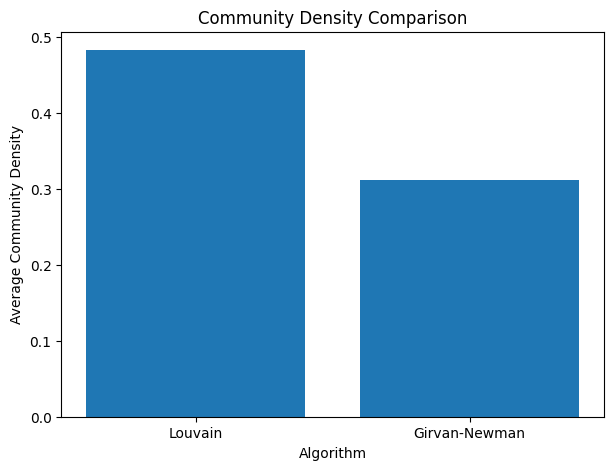

In [29]:

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Average_Community_Density"]
)

plt.ylabel("Average Community Density")
plt.xlabel("Algorithm")
plt.title("Community Density Comparison")

plt.show()



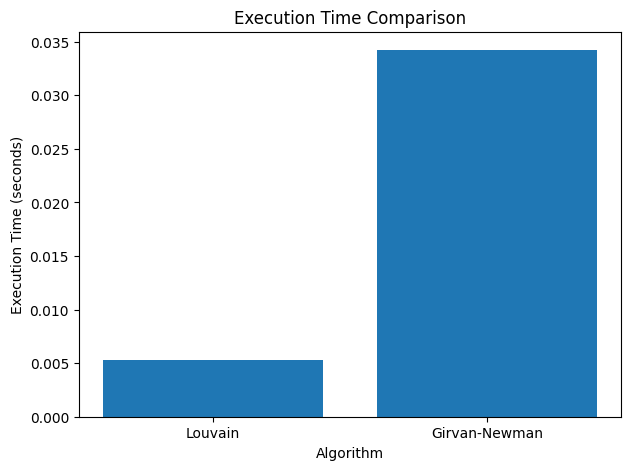

In [30]:

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Execution_Time_Seconds"]
)

plt.ylabel("Execution Time (seconds)")
plt.xlabel("Algorithm")
plt.title("Execution Time Comparison")

plt.show()

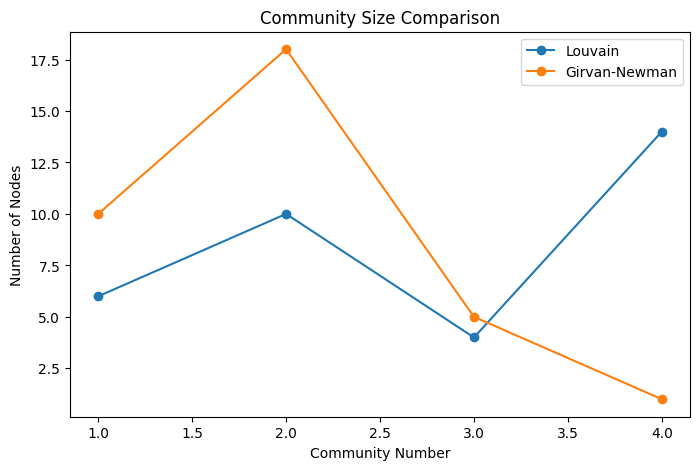

In [32]:

# COMMUNITY SIZE COMPARISON


louvain_sizes = [
    len(c)
    for c in louvain_communities_result
]

gn_sizes = [
    len(c)
    for c in gn_4_communities
]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(louvain_sizes) + 1),
    louvain_sizes,
    marker="o",
    label="Louvain"
)

plt.plot(
    range(1, len(gn_sizes) + 1),
    gn_sizes,
    marker="o",
    label="Girvan-Newman"
)

plt.xlabel("Community Number")
plt.ylabel("Number of Nodes")
plt.title("Community Size Comparison")
plt.legend()

plt.show()

CENTRALITY ANALYSIS

In [33]:


degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame(
    degree_centrality.items(),
    columns=["Node", "Degree_Centrality"]
)

degree_df = degree_df.sort_values(
    "Degree_Centrality",
    ascending=False
)

print("===== TOP 10 NODES BY DEGREE CENTRALITY =====")

display(degree_df.head(10))

===== TOP 10 NODES BY DEGREE CENTRALITY =====


,Node,Degree_Centrality
33,33,0.515152
0,0,0.484848
32,32,0.363636
2,2,0.303030
1,1,0.272727
3,3,0.181818
31,31,0.181818
23,23,0.151515
8,8,0.151515
13,13,0.151515


In [35]:


betweenness_centrality = nx.betweenness_centrality(G)

betweenness_df = pd.DataFrame(
    betweenness_centrality.items(),
    columns=["Node", "Betweenness_Centrality"]
)

betweenness_df = betweenness_df.sort_values(
    "Betweenness_Centrality",
    ascending=False
)

print("===== TOP 10 NODES BY BETWEENNESS CENTRALITY =====")

display(betweenness_df.head(10))

===== TOP 10 NODES BY BETWEENNESS CENTRALITY =====


,Node,Betweenness_Centrality
0,0,0.437635
33,33,0.304075
32,32,0.145247
2,2,0.143657
31,31,0.138276
8,8,0.055927
1,1,0.053937
13,13,0.045863
19,19,0.032475
5,5,0.029987


In [36]:


closeness_centrality = nx.closeness_centrality(G)

closeness_df = pd.DataFrame(
    closeness_centrality.items(),
    columns=["Node", "Closeness_Centrality"]
)

closeness_df = closeness_df.sort_values(
    "Closeness_Centrality",
    ascending=False
)

print("===== TOP 10 NODES BY CLOSENESS CENTRALITY =====")

display(closeness_df.head(10))

===== TOP 10 NODES BY CLOSENESS CENTRALITY =====


,Node,Closeness_Centrality
0,0,0.568966
2,2,0.559322
33,33,0.550000
31,31,0.540984
13,13,0.515625
8,8,0.515625
32,32,0.515625
19,19,0.500000
1,1,0.485294
3,3,0.464789


In [37]:


eigenvector_centrality = nx.eigenvector_centrality(
    G,
    max_iter=1000
)

eigenvector_df = pd.DataFrame(
    eigenvector_centrality.items(),
    columns=["Node", "Eigenvector_Centrality"]
)

eigenvector_df = eigenvector_df.sort_values(
    "Eigenvector_Centrality",
    ascending=False
)

print("===== TOP 10 NODES BY EIGENVECTOR CENTRALITY =====")

display(eigenvector_df.head(10))

===== TOP 10 NODES BY EIGENVECTOR CENTRALITY =====


,Node,Eigenvector_Centrality
33,33,0.373371
0,0,0.355483
2,2,0.317189
32,32,0.308651
1,1,0.265954
8,8,0.227405
13,13,0.226470
3,3,0.211174
31,31,0.191036
30,30,0.174760


In [38]:

centrality_df = pd.DataFrame({

    "Node": list(G.nodes()),

    "Degree_Centrality": [
        degree_centrality[n]
        for n in G.nodes()
    ],

    "Betweenness_Centrality": [
        betweenness_centrality[n]
        for n in G.nodes()
    ],

    "Closeness_Centrality": [
        closeness_centrality[n]
        for n in G.nodes()
    ],

    "Eigenvector_Centrality": [
        eigenvector_centrality[n]
        for n in G.nodes()
    ]
})

display(centrality_df.head())

,Node,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Eigenvector_Centrality
0,0,0.484848,0.437635,0.568966,0.355483
1,1,0.272727,0.053937,0.485294,0.265954
2,2,0.303030,0.143657,0.559322,0.317189
3,3,0.181818,0.011909,0.464789,0.211174
4,4,0.090909,0.000631,0.379310,0.075966


INFLUENCE SCORE

In [39]:
centrality_df["Influence_Score"] = (

    0.25 * centrality_df["Degree_Centrality"]

    + 0.30 * centrality_df["Betweenness_Centrality"]

    + 0.20 * centrality_df["Closeness_Centrality"]

    + 0.25 * centrality_df["Eigenvector_Centrality"]
)

In [41]:
influence_df = centrality_df.sort_values(
    "Influence_Score",
    ascending=False
).reset_index(drop=True)

influence_df["Rank"] = (
    influence_df.index + 1
)


influence_df = influence_df[
    [
        "Rank",
        "Node",
        "Degree_Centrality",
        "Betweenness_Centrality",
        "Closeness_Centrality",
        "Eigenvector_Centrality",
        "Influence_Score"
    ]
]

print("===== TOP 10 INFLUENTIAL NODES ====")

display(
    influence_df.head(10)
)

===== TOP 10 INFLUENTIAL NODES ====


,Rank,Node,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Eigenvector_Centrality,Influence_Score
0,1,0,0.484848,0.437635,0.568966,0.355483,0.455167
1,2,33,0.515152,0.304075,0.550000,0.373371,0.423353
2,3,32,0.363636,0.145247,0.515625,0.308651,0.314771
3,4,2,0.303030,0.143657,0.559322,0.317189,0.310016
4,5,1,0.272727,0.053937,0.485294,0.265954,0.247910
5,6,31,0.181818,0.138276,0.540984,0.191036,0.242893
6,7,8,0.151515,0.055927,0.515625,0.227405,0.214633
7,8,13,0.151515,0.045863,0.515625,0.226470,0.211380
8,9,3,0.181818,0.011909,0.464789,0.211174,0.194779
9,10,30,0.121212,0.014412,0.458333,0.174760,0.169983


In [42]:
influence_df["Louvain_Community"] = (
    influence_df["Node"].map(louvain_labels)
)

print("===== INFLUENTIAL NODES WITH COMMUNITIES =====")

display(
    influence_df.head(10)
)

===== INFLUENTIAL NODES WITH COMMUNITIES =====


,Rank,Node,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Eigenvector_Centrality,Influence_Score,Louvain_Community
0,1,0,0.484848,0.437635,0.568966,0.355483,0.455167,1
1,2,33,0.515152,0.304075,0.550000,0.373371,0.423353,3
2,3,32,0.363636,0.145247,0.515625,0.308651,0.314771,3
3,4,2,0.303030,0.143657,0.559322,0.317189,0.310016,0
4,5,1,0.272727,0.053937,0.485294,0.265954,0.247910,0
5,6,31,0.181818,0.138276,0.540984,0.191036,0.242893,2
6,7,8,0.151515,0.055927,0.515625,0.227405,0.214633,3
7,8,13,0.151515,0.045863,0.515625,0.226470,0.211380,0
8,9,3,0.181818,0.011909,0.464789,0.211174,0.194779,0
9,10,30,0.121212,0.014412,0.458333,0.174760,0.169983,3


In [43]:

bridge_df = influence_df.sort_values(
    "Betweenness_Centrality",
    ascending=False
)

print("===== TOP 10 BRIDGE NODES =====")

display(
    bridge_df[
        [
            "Node",
            "Betweenness_Centrality",
            "Louvain_Community"
        ]
    ].head(10)
)

===== TOP 10 BRIDGE NODES =====


,Node,Betweenness_Centrality,Louvain_Community
0,0,0.437635,1
1,33,0.304075,3
2,32,0.145247,3
3,2,0.143657,0
5,31,0.138276,2
6,8,0.055927,3
4,1,0.053937,0
7,13,0.045863,0
10,19,0.032475,1
16,5,0.029987,1


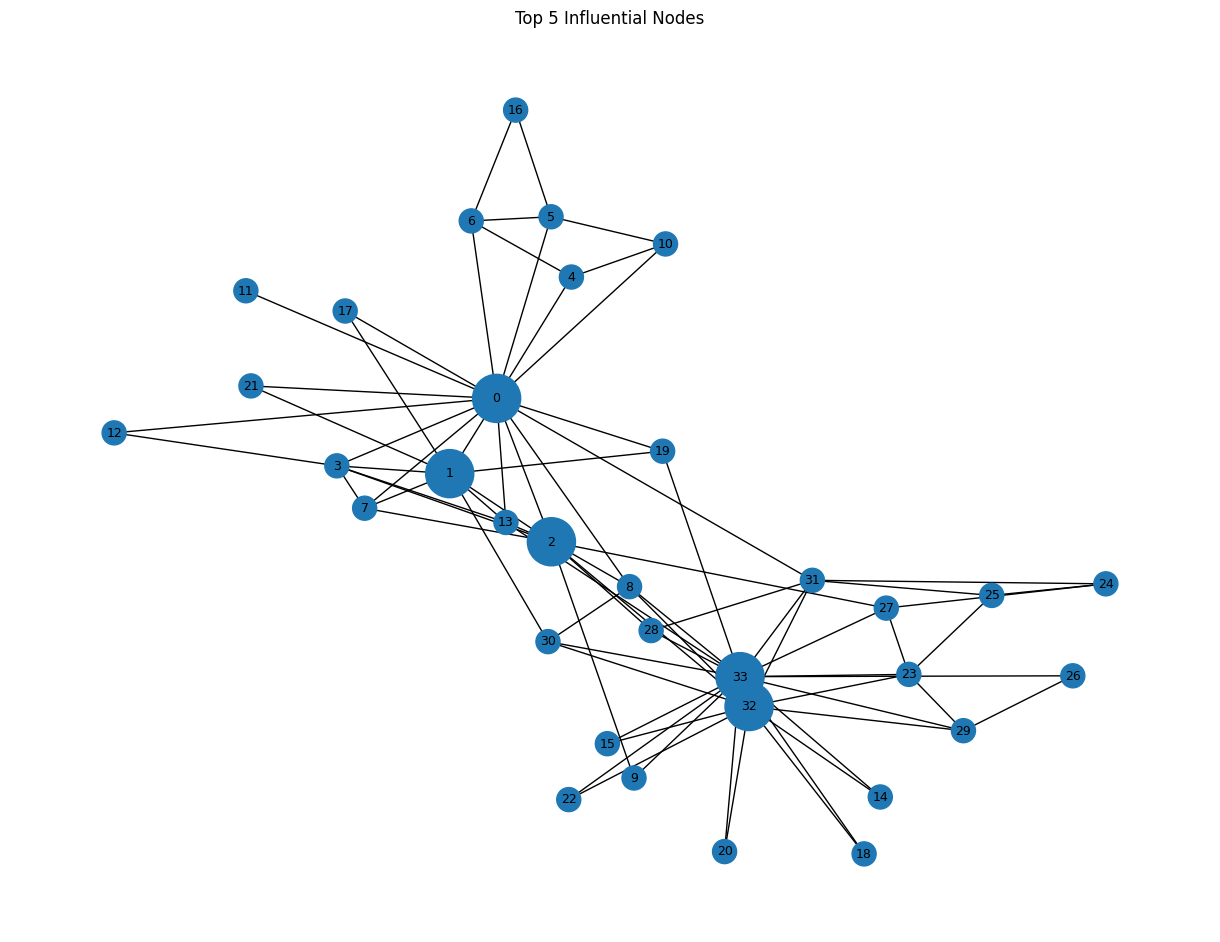

In [44]:

top_5_nodes = set(
    influence_df.head(5)["Node"]
)

node_sizes = []

for node in G.nodes():

    if node in top_5_nodes:
        node_sizes.append(1200)
    else:
        node_sizes.append(300)

plt.figure(figsize=(12, 9))

nx.draw(
    G,
    pos,
    node_size=node_sizes,
    with_labels=True,
    font_size=9
)

plt.title(
    "Top 5 Influential Nodes"
)

plt.show()

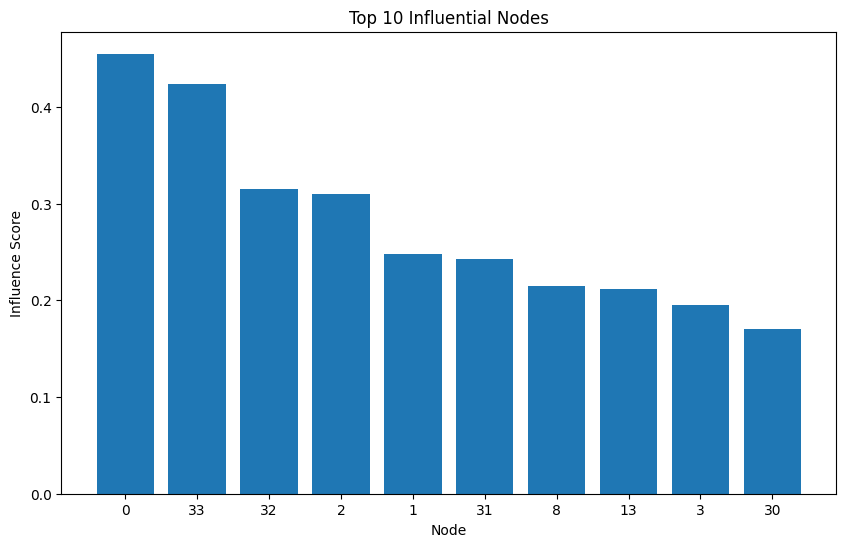

In [45]:

top10 = influence_df.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top10["Node"].astype(str),
    top10["Influence_Score"]
)

plt.xlabel("Node")
plt.ylabel("Influence Score")
plt.title("Top 10 Influential Nodes")

plt.show()

In [46]:


final_comparison = pd.DataFrame({

    "Algorithm": [
        "Louvain",
        "Girvan-Newman"
    ],

    "Number of Communities": [
        len(louvain_communities_result),
        len(gn_4_communities)
    ],

    "Modularity": [
        louvain_modularity,
        gn_modularity_4
    ],

    "Average Community Density": [
        louvain_avg_density,
        gn_avg_density
    ],

    "Execution Time (seconds)": [
        louvain_time,
        gn_time
    ]
})

print("===== FINAL ALGORITHM COMPARISON =====")

display(final_comparison)

===== FINAL ALGORITHM COMPARISON =====


,Algorithm,Number of Communities,Modularity,Average Community Density,Execution Time (seconds)
0,Louvain,4,0.426622,0.482540,0.005265
1,Girvan-Newman,4,0.358061,0.312092,0.034223


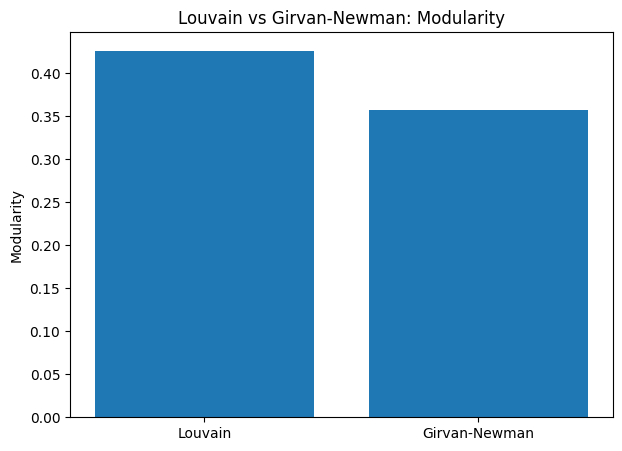

In [48]:


community_size_table = pd.DataFrame({

    "Louvain Community": [
        len(c)
        for c in louvain_communities_result
    ],

    "Girvan-Newman Community": [
        len(c)
        for c in gn_4_communities
    ]
})

print("===== COMMUNITY SIZE COMPARISON =====")

display(community_size_table)

===== COMMUNITY SIZE COMPARISON =====


,Louvain Community,Girvan-Newman Community
0,6,10
1,10,18
2,4,5
3,14,1


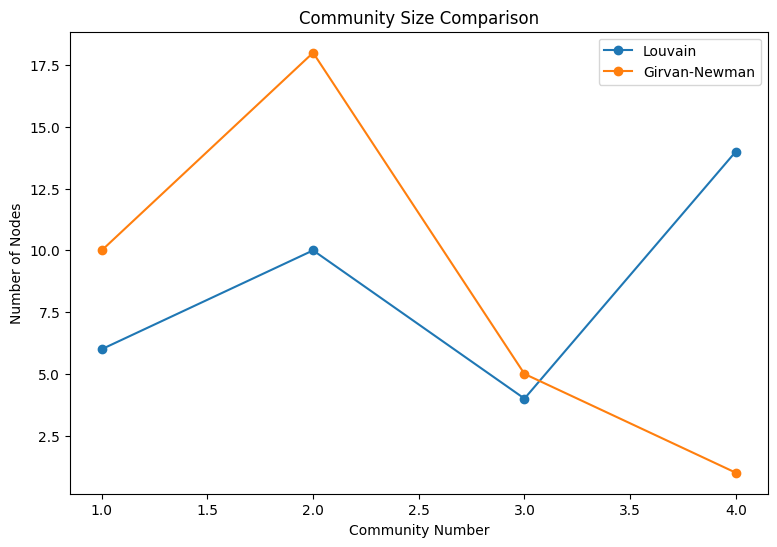

In [49]:

community_numbers = range(
    1,
    len(louvain_communities_result) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    community_numbers,
    community_size_table["Louvain Community"],
    marker="o",
    label="Louvain"
)

plt.plot(
    community_numbers,
    community_size_table["Girvan-Newman Community"],
    marker="o",
    label="Girvan-Newman"
)

plt.xlabel("Community Number")
plt.ylabel("Number of Nodes")

plt.title(
    "Community Size Comparison"
)

plt.legend()

plt.show()

In [50]:

top_degree_nodes = (
    degree_df.head(10)["Node"].tolist()
)

top_betweenness_nodes = (
    betweenness_df.head(10)["Node"].tolist()
)

top_closeness_nodes = (
    closeness_df.head(10)["Node"].tolist()
)

top_eigenvector_nodes = (
    eigenvector_df.head(10)["Node"].tolist()
)

print("Top Degree Nodes:")
print(top_degree_nodes)

print("\nTop Betweenness Nodes:")
print(top_betweenness_nodes)

print("\nTop Closeness Nodes:")
print(top_closeness_nodes)

print("\nTop Eigenvector Nodes:")
print(top_eigenvector_nodes)

Top Degree Nodes:
[33, 0, 32, 2, 1, 3, 31, 23, 8, 13]

Top Betweenness Nodes:
[0, 33, 32, 2, 31, 8, 1, 13, 19, 5]

Top Closeness Nodes:
[0, 2, 33, 31, 13, 8, 32, 19, 1, 3]

Top Eigenvector Nodes:
[33, 0, 2, 32, 1, 8, 13, 3, 31, 30]


In [51]:
from collections import Counter

all_top_nodes = (
    top_degree_nodes
    + top_betweenness_nodes
    + top_closeness_nodes
    + top_eigenvector_nodes
)

node_frequency = Counter(all_top_nodes)

frequency_df = pd.DataFrame(
    node_frequency.items(),
    columns=["Node", "Number_of_Top10_Appearances"]
)

frequency_df = frequency_df.sort_values(
    "Number_of_Top10_Appearances",
    ascending=False
)

print("===== NODES APPEARING MOST OFTEN IN TOP-10 RANKINGS =====")

display(frequency_df.head(10))

===== NODES APPEARING MOST OFTEN IN TOP-10 RANKINGS =====


,Node,Number_of_Top10_Appearances
0,33,4
1,0,4
2,32,4
3,2,4
4,1,4
6,31,4
8,8,4
9,13,4
5,3,3
10,19,2


In [52]:
final_influential = influence_df.copy()

final_influential["Louvain_Community"] = (
    final_influential["Node"].map(louvain_labels)
)

print("===== FINAL INFLUENTIAL NODE ANALYSIS =====")

display(
    final_influential.head(10)
)

===== FINAL INFLUENTIAL NODE ANALYSIS =====


,Rank,Node,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Eigenvector_Centrality,Influence_Score,Louvain_Community
0,1,0,0.484848,0.437635,0.568966,0.355483,0.455167,1
1,2,33,0.515152,0.304075,0.550000,0.373371,0.423353,3
2,3,32,0.363636,0.145247,0.515625,0.308651,0.314771,3
3,4,2,0.303030,0.143657,0.559322,0.317189,0.310016,0
4,5,1,0.272727,0.053937,0.485294,0.265954,0.247910,0
5,6,31,0.181818,0.138276,0.540984,0.191036,0.242893,2
6,7,8,0.151515,0.055927,0.515625,0.227405,0.214633,3
7,8,13,0.151515,0.045863,0.515625,0.226470,0.211380,0
8,9,3,0.181818,0.011909,0.464789,0.211174,0.194779,0
9,10,30,0.121212,0.014412,0.458333,0.174760,0.169983,3


In [53]:

final_comparison.to_csv(
    "algorithm_comparison.csv",
    index=False
)

final_influential.to_csv(
    "influential_nodes.csv",
    index=False
)

frequency_df.to_csv(
    "centrality_ranking_frequency.csv",
    index=False
)

community_size_table.to_csv(
    "community_sizes.csv",
    index=False
)

print("All result files saved successfully!")

All result files saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>